**Imports**

In [1]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from numba import njit, prange

In [2]:
data = pandas.read_csv('sdss_cutout.csv')
z = data['Z'].values
z_mask = (z > 0.08) & (z < 0.12)
data = data[z_mask].reset_index(drop=True)
#print(data)
u_mag = data['phot_u'].values
r_mag = data['phot_r'].values
color = u_mag - r_mag

red_gal = data[color > 2.3].reset_index(drop=True)
blue_gal = data[color <= 2.3].reset_index(drop=True)

red_gal_ra = red_gal['RA'].values
red_gal_dec = red_gal['DEC'].values

blue_gal_ra = blue_gal['RA'].values
blue_gal_dec = blue_gal['DEC'].values

In [3]:
# Since the red and blue samples have different sized we need to use those when creating our random samples.
red_len = len(red_gal)
blue_len = len(blue_gal)

# According to the NumPy documentation, this is the recommended way to create a sample from a uniform distribution.
rand = np.random.default_rng()

red_ra_rand = rand.uniform(130, 230, red_len)
red_dec_rand = rand.uniform(5, 65, red_len)

blue_ra_rand = rand.uniform(130, 230, blue_len)
blue_dec_rand = rand.uniform(5, 65, blue_len)

omega_bins = np.geomspace(0.003, 0.3, 11)

In [4]:
# To use our samples with the logarithmically spaced bins in radians, we have to convert our coordinates into sperical ones.
def ra_dec_to_spherical(ra, dec):
    phi = np.pi * (ra/180)
    theta = np.pi/2 - np.pi * (dec/180)
    return phi, theta

In [ ]:
# Conversion

red_phi, red_theta = ra_dec_to_spherical(red_gal_ra, red_gal_dec)
blue_phi, blue_theta = ra_dec_to_spherical(blue_gal_ra, blue_gal_dec)

red_phi_rand, red_theta_rand = ra_dec_to_spherical(red_ra_rand, red_dec_rand)
blue_phi_rand, blue_theta_rand = ra_dec_to_spherical(blue_ra_rand, blue_dec_rand)

In [6]:
@njit(parallel=True)
def count_pairs(delta1, delta2, alpha1, alpha2, edges, auto=False):
    bin_num = len(edges) - 1
    counts = np.zeros(bin_num, dtype=np.int64)

    for i in prange(len(alpha1)):
        cos_a = np.cos(alpha1[i])
        sin_a = np.sin(alpha1[i])
        delta = delta1[i]

        j_start = i + 1 if auto else 0

        for j in range(j_start, len(alpha2)):
            omega = np.arccos(cos_a * np.cos(alpha2[j]) + np.cos(delta - delta2[j]) * sin_a * np.sin(alpha2[j]))

            for k in range(bin_num):
                if edges[k] <= omega < edges[k + 1]:
                    counts[k] += 1
                    break
    return counts

In [ ]:
red_DD = count_pairs(red_phi, red_phi, red_theta, red_theta, omega_bins, auto=True)
red_RR = count_pairs(red_phi_rand, red_phi_rand, red_theta_rand, red_theta_rand, omega_bins, auto=True)
red_DR = count_pairs(red_phi, red_phi_rand, red_theta, red_theta_rand, omega_bins, auto=False)

In [ ]:
blue_DD = count_pairs(blue_phi, blue_phi, blue_theta, blue_theta, omega_bins, auto=True)
blue_RR = count_pairs(blue_phi_rand, blue_phi_rand, blue_theta_rand, blue_theta_rand, omega_bins, auto=True)
blue_DR = count_pairs(blue_phi, blue_phi_rand, blue_theta, blue_theta_rand, omega_bins, auto=False)

In [9]:
print(red_DD)
print(red_RR)
print(red_DR)

[    99957    216045    481196   1100722   2559310   5932266  13555940
  30300024  66105719 132342924]
[    57909    145685    364716    904989   2245111   5535507  13472503
  32179594  73715178 158281690]
[   107583    268293    672652   1670484   4151157  10228462  24889009
  59444188 137438866 302338763]


In [10]:
print(blue_DD)
print(blue_RR)
print(blue_DR)

[   19100    44920   106498   255800   605726  1437632  3389427  7801891
 17466116 36120095]
[   14628    36613    91626   228692   566673  1395252  3400482  8129400
 18649656 39928730]
[   26715    68141   170022   425450  1059614  2618054  6397858 15331330
 35564127 78035027]


In [11]:
def landy_szalay(DD, RR, DR, num):
    return 1 + DD/RR - (num -1)/num * DR/RR

In [12]:
red_xi = landy_szalay(red_DD, red_RR, red_DR, red_len)
print(red_xi)

blue_xi = landy_szalay(blue_DD, blue_RR, blue_DR, blue_len)
print(blue_xi)

[ 0.86834125  0.64139358  0.47508497  0.37045151  0.29100229  0.22391438
  0.1588305   0.09435825  0.03234472 -0.07397675]
[ 0.47948299  0.36583283  0.30676427  0.25823365  0.19909152  0.1540338
  0.11535455  0.07386331  0.02964198 -0.04967951]


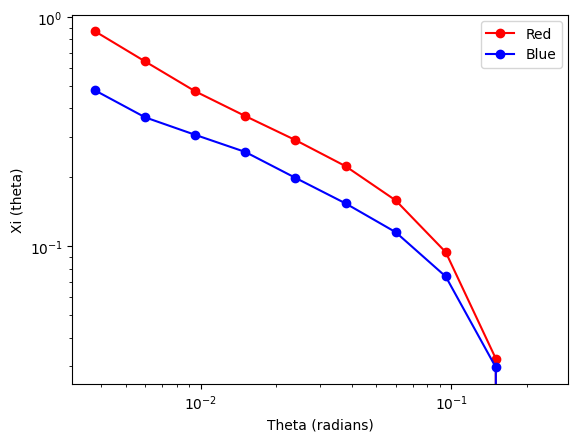

In [23]:
# We need to compute the geometric mean first. We can't use the arithmic mean since our bins are log spaced.
bin_midpoints = np.sqrt(omega_bins[:-1] * omega_bins[1:])
#degree_points = np.degrees(bin_midpoints)
plt.loglog(bin_midpoints, red_xi, 'o-', c='red', label='Red')
plt.loglog(bin_midpoints, blue_xi, 'o-', c='blue', label='Blue')
plt.xlabel('Theta (radians)')
plt.ylabel('Xi (theta)')
plt.legend()
plt.show()

**Task 6**

In [18]:
jack_knife_regions = 6
# We only slice the data in the RA direction to save on computation time.
ra_edges = np.linspace(130, 230, jack_knife_regions + 1)

red_region = np.digitize(red_gal_ra, ra_edges[1:-1])
red_region_rand = np.digitize(red_ra_rand, ra_edges[1:-1])

blue_region = np.digitize(blue_gal_ra, ra_edges[1:-1])
blue_region_rand = np.digitize(blue_ra_rand, ra_edges[1:-1])

red_xi_samples = []
blue_xi_samples = []

In [ ]:
for k in range(jack_knife_regions):
    red_mask = red_region != k
    red_mask_rand = red_region_rand != k

    blue_mask = blue_region != k
    blue_mask_rand = blue_region_rand != k

    red_DD_k = count_pairs(red_phi[red_mask], red_phi[red_mask], red_theta[red_mask], red_theta[red_mask], omega_bins, auto=True)
    red_RR_k = count_pairs(red_phi_rand[red_mask_rand], red_phi_rand[red_mask_rand], red_theta_rand[red_mask_rand], red_theta_rand[red_mask_rand], omega_bins, auto=True)
    red_DR_k = count_pairs(red_phi[red_mask], red_phi_rand[red_mask_rand], red_theta[red_mask], red_theta_rand[red_mask_rand], omega_bins, auto=False)

    blue_DD_k = count_pairs(blue_phi[blue_mask], blue_phi[blue_mask], blue_theta[blue_mask], blue_theta[blue_mask], omega_bins, auto=True)
    blue_RR_k = count_pairs(blue_phi_rand[blue_mask_rand], blue_phi_rand[blue_mask_rand], blue_theta_rand[blue_mask_rand], blue_theta_rand[blue_mask_rand], omega_bins, auto=True)
    blue_DR_k = count_pairs(blue_phi[blue_mask], blue_phi_rand[blue_mask_rand], blue_theta[blue_mask], blue_theta_rand[blue_mask_rand], omega_bins, auto=False)

    xi_red_k = landy_szalay(red_DD_k, red_RR_k, red_DR_k, np.sum(red_mask))
    xi_blue_k = landy_szalay(blue_DD_k, blue_RR_k, blue_DR_k, np.sum(blue_mask))

    red_xi_samples.append(xi_red_k)
    blue_xi_samples.append(xi_blue_k)

In [21]:
red_xi_all = np.array(red_xi_samples)
blue_xi_all = np.array(blue_xi_samples)

red_xi_mean = np.mean(red_xi_all, axis=0)
red_xi_std = np.std(red_xi_all, axis=0)

blue_xi_mean = np.mean(blue_xi_all, axis=0)
blue_xi_std = np.std(blue_xi_all, axis=0)

# From the equation in the lecture.
red_xi_var = ((jack_knife_regions - 1) / jack_knife_regions) * np.sum((red_xi_all - red_xi_mean)**2, axis=0)
red_xi_err = np.sqrt(red_xi_var)

blue_xi_var = ((jack_knife_regions - 1) / jack_knife_regions) * np.sum((blue_xi_all - blue_xi_mean)**2, axis=0)
blue_xi_err = np.sqrt(blue_xi_var)

print("Red xi error:", red_xi_err)
print("Blue xi error:", blue_xi_err)

Red xi error: [0.10082712 0.07583892 0.06004632 0.05457008 0.04993336 0.04110424
 0.03316036 0.02900397 0.02607359 0.01911026]
Blue xi error: [0.03643332 0.03373932 0.03183652 0.02780336 0.02428752 0.0228903
 0.01935112 0.01795558 0.02026468 0.02850094]


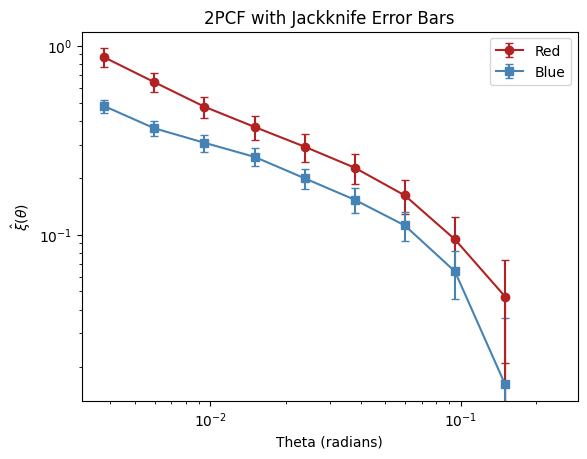

In [26]:
fig, ax = plt.subplots()

ax.errorbar(bin_midpoints, red_xi_mean, yerr=red_xi_err, fmt='o-', c='firebrick', capsize=3, label='Red')
ax.errorbar(bin_midpoints, blue_xi_mean, yerr=blue_xi_err, fmt='s-', c='steelblue', capsize=3, label='Blue')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Theta (radians)')
ax.set_ylabel(r'$\hat{\xi}(\theta)$')
ax.set_title('2PCF with Jackknife Error Bars')
ax.legend()
plt.show()